# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

## Question 1

**1. What makes a model “linear”? “Linear” in what?**  
A model is linear when it is linear in the parameters/coefficient terms, not necessarily in the variables themselves. For example, y=B0+B_1x+B_2x^2 is still linear because the B's enter linearly.

**2. How do you interpret the coefficient for a dummy/one-hot encoded variable?**  
A dummy variable coefficient is interpreted relative to the reference group. If the model includes an intercept, the intercept is the mean outcome for the omitted group, and the dummy coefficient tells us how much higher or lower that group is compared to the reference group.

**3. Can linear regression be used for classification? Explain why, or why not.**  
It can be used as a rough classifier, but it is not ideal for classification because it can predict values below 0 or above 1 and does not model probabilities correctly. Logistic regression is usually a better choice.

**4. What are signs that your linear model is over-fitting?**  
Signs of overfitting include very low training error, much higher test or validation error, unstable coefficients, and predictions that change a lot across samples.

**5. Clearly explain multicollinearity using the two-stage least squares technique.**  
Multicollinearity means one predictor can be explained really well by the other predictors, so it does not add much independent information. In a first-stage regression, if one x is highly predicted by the other x's, then in the second stage it becomes hard to isolate that variable’s separate effect on y. This makes the coefficient unstable and increases its standard error.

**6. How can you incorporate nonlinear relationships between y and x into your analysis?**  
You can add transformed or higher-order terms such as x^2, x^3, log(x), interaction terms, splines, or piecewise functions. This allows the model to capture curvature while still using linear regression methods.

**7. What is the interpretation of the slope coefficient in a linear regression?**  
The slope coefficient is the expected change in y from a one-unit increase in x, holding the other variables constant.

**8. Compare the train/test split and k-fold cross validation.**  
A train/test split uses one fixed split of the data, so it is simple but depends a lot on that one split. k-fold cross validation repeatedly splits the data into k parts, trains on k, tests on the remaining fold, and averages the results, so it usually gives a more stable estimate of model performance.

**9. How is the k in k-fold cross validation typically selected?**  
k is usually chosen as 5 or 10 because those are good practical tradeoffs between speed and stability. Smaller k is faster, while larger k uses more data for training in each round.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

                Price  Review_Scores_Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive on average: Manhattan


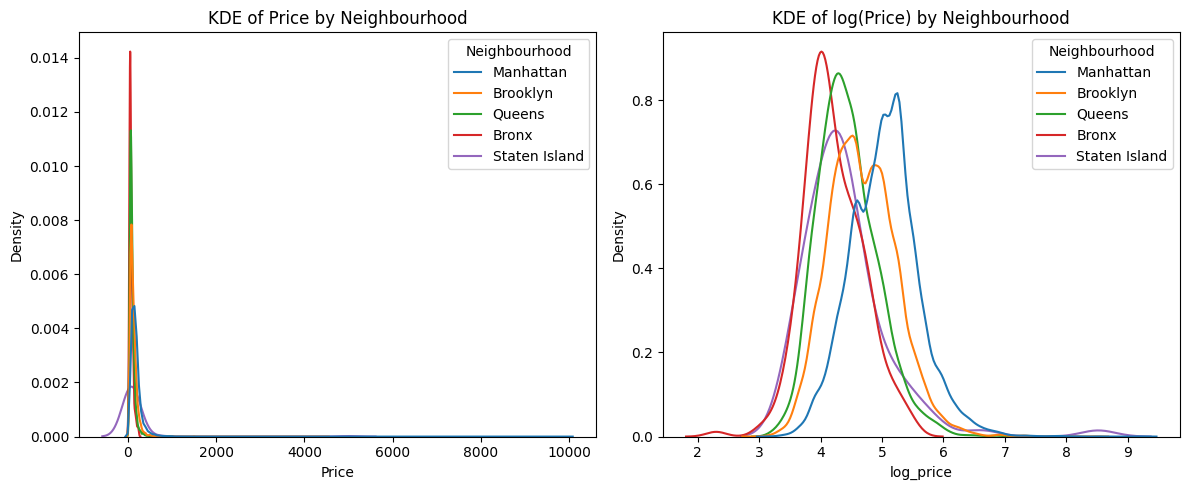

In [28]:
# 2.1

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df = df.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})

df = df[['Price', 'Review_Scores_Rating', 'Neighbourhood']].dropna().copy()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Review_Scores_Rating'] = pd.to_numeric(df['Review_Scores_Rating'], errors='coerce')
df['Neighbourhood'] = df['Neighbourhood'].astype(str).str.strip()
df = df.dropna()

avg_table = (
    df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']]
      .mean()
      .sort_values('Price', ascending=False)
)

print(avg_table.round(2))
print("\nMost expensive on average:", avg_table.index[0])

df['log_price'] = np.log(df['Price'])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(data=df, x='Price', hue='Neighbourhood', common_norm=False)
plt.title('KDE of Price by Neighbourhood')

plt.subplot(1,2,2)
sns.kdeplot(data=df, x='log_price', hue='Neighbourhood', common_norm=False)
plt.title('KDE of log(Price) by Neighbourhood')

plt.tight_layout()
plt.show()

In [29]:
# 2.2
import statsmodels.formula.api as smf

df['Neighbourhood'] = pd.Categorical(
    df['Neighbourhood'],
    categories=['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
)

m2 = smf.ols('Price ~ C(Neighbourhood)', data=df).fit()
print(m2.summary())

print("\nCoefficients:")
print(m2.params.round(4))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        22:31:12   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

# 2.2 answer: 
I kept the intercept and dropped Bronx as the reference group. So the intercept is the mean of the omitted borough, and each dummy coefficient is the difference between that borough’s mean and the omitted borough’s mean.

In [30]:
# 2.3
m3 = smf.ols('Price ~ Review_Scores_Rating', data=df).fit()
print(m3.summary())

print("\nCoefficients:")
print(m3.params.round(4))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:31:12   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

# 2.3 answer:
The slope on `Review Scores Rating` is 1.0208. This means a 1-point increase in review score is associated with about a \$1.02 increase in nightly price, on average.

In [31]:
# 2.4
import pandas as pd
import statsmodels.formula.api as smf

df['Neighbourhood'] = pd.Categorical(
    df['Neighbourhood'],
    categories=['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
)

m4 = smf.ols('Price ~ C(Neighbourhood) + Review_Scores_Rating', data=df).fit()
print(m4.summary())

print("\nCoefficients:")
print(m4.params.round(4))

mean_rating = df['Review_Scores_Rating'].mean()
pred_df = pd.DataFrame({
    'Neighbourhood': ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island'],
    'Review_Scores_Rating': [mean_rating] * 5
})

pred_df['Neighbourhood'] = pd.Categorical(
    pred_df['Neighbourhood'],
    categories=df['Neighbourhood'].cat.categories
)

pred_df['predicted_price_at_avg_rating'] = m4.predict(pred_df)

print("\nPredicted prices at average review score:")
print(pred_df.round(2))

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        22:31:12   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

# 2.4 answer: 
After adding neighborhood controls, the slope on `Review Scores Rating` becomes 1.0811, which is only slightly larger than before. So holding neighborhood fixed, a 1-point increase in review score is associated with about a \$1.08 increase in price. The neighborhood effects change very little, so neighborhood explains much more of the price differences than review score does.


In [32]:
# 2.5
m5 = smf.ols('Price ~ C(Neighbourhood) * Review_Scores_Rating', data=df).fit()
print(m5.summary())

slopes = {
    'Bronx': m5.params['Review_Scores_Rating'],
    'Brooklyn': m5.params['Review_Scores_Rating'] + m5.params['C(Neighbourhood)[T.Brooklyn]:Review_Scores_Rating'],
    'Manhattan': m5.params['Review_Scores_Rating'] + m5.params['C(Neighbourhood)[T.Manhattan]:Review_Scores_Rating'],
    'Queens': m5.params['Review_Scores_Rating'] + m5.params['C(Neighbourhood)[T.Queens]:Review_Scores_Rating'],
    'Staten Island': m5.params['Review_Scores_Rating'] + m5.params['C(Neighbourhood)[T.Staten Island]:Review_Scores_Rating'],
}

print("\nSlope on Review_Scores_Rating by borough:")
for k, v in slopes.items():
    print(f"{k}: {v:.4f}")

print("\nCounts by borough:")
print(df['Neighbourhood'].value_counts())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:31:12   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

# 2.5 answer:

The slopes are fairly similar for Bronx, Brooklyn, Manhattan, and Queens, since they all fall roughly between 0.5 and 1.3.

Staten Island is the exception, but it has a much smaller sample size, so that estimate is probably less stable. Overall, the slopes look mostly similar across the main boroughs.

In [33]:
# 2.6
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

X = df[['Neighbourhood', 'Review_Scores_Rating']]
y = df['Price']

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Review only
X3 = df[['Review_Scores_Rating']]
pipe3 = Pipeline([
    ('model', LinearRegression())
])
scores3 = cross_validate(pipe3, X3, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))

# Neighbourhood + Review
pipe4 = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Neighbourhood']),
        ('num', 'passthrough', ['Review_Scores_Rating'])
    ])),
    ('model', LinearRegression())
])
scores4 = cross_validate(pipe4, X, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))

# Neighbourhood × Review
pipe5 = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), ['Neighbourhood']),
        ('num', 'passthrough', ['Review_Scores_Rating'])
    ])),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('model', LinearRegression())
])
scores5 = cross_validate(pipe5, X, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))

cv_results = pd.DataFrame({
    'Model': ['Review only', 'Neighbourhood + Review', 'Neighbourhood x Review'],
    'Mean CV MSE': [
        -scores3['test_neg_mean_squared_error'].mean(),
        -scores4['test_neg_mean_squared_error'].mean(),
        -scores5['test_neg_mean_squared_error'].mean()
    ],
    'Mean CV RMSE': [
        np.sqrt(-scores3['test_neg_mean_squared_error'].mean()),
        np.sqrt(-scores4['test_neg_mean_squared_error'].mean()),
        np.sqrt(-scores5['test_neg_mean_squared_error'].mean())
    ],
    'Mean CV R^2': [
        scores3['test_r2'].mean(),
        scores4['test_r2'].mean(),
        scores5['test_r2'].mean()
    ]
})

print(cv_results.round(4))

                    Model  Mean CV MSE  Mean CV RMSE  Mean CV R^2
0             Review only   22078.7876      148.5893       0.0041
1  Neighbourhood + Review   21070.1423      145.1556       0.0576
2  Neighbourhood x Review   21328.1834      146.0417       0.0411


# 2.6 answer:
The best model is Question 2.4, the additive model with Neighbourhood + Review Scores Rating.

It predicts better out of sample than using review score alone, and it also performs better than the more complicated interaction model.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


Overall Price summary:
count        976.00
mean      741019.47
std       367323.38
min       188000.00
25%       475750.00
50%       666500.00
75%       883000.00
max      2941000.00
Name: Price, dtype: float64

Price summary by Body_Type:
           count        mean        std       min       25%        50%  \
Body_Type                                                                
crossover   21.0   705095.24   72849.78  608000.0  638000.0   706000.0   
hatchback  484.0   533977.27  173086.73  188000.0  401750.0   509000.0   
muv         38.0   626421.05  184093.49  328000.0  489750.0   621500.0   
sedan      227.0   809784.14  286736.77  368000.0  598000.0   772000.0   
suv        206.0  1176495.15  417479.03  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


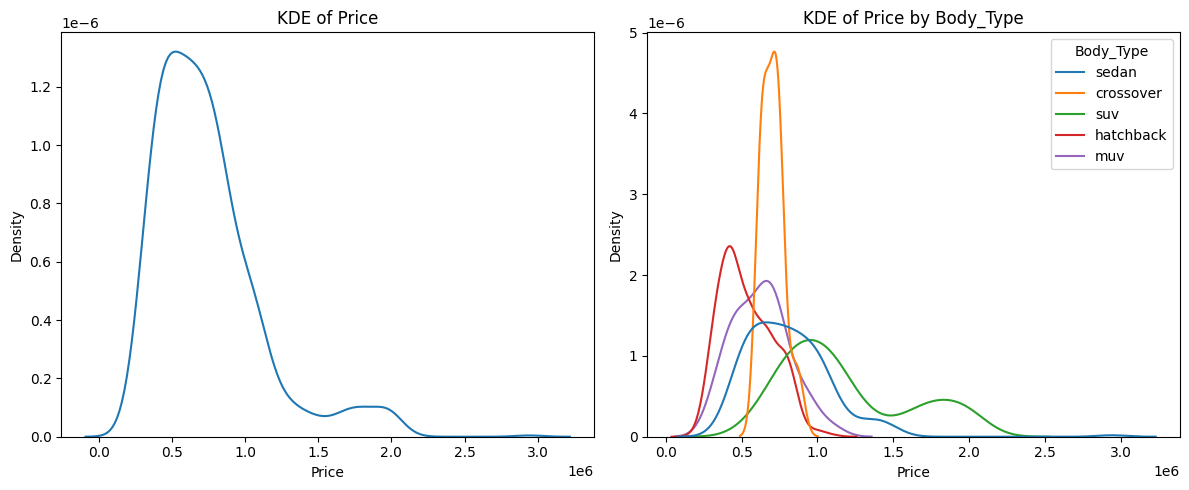

In [34]:
# 3.1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('./data/cars_hw.csv')
df.columns = df.columns.str.strip()

print("Overall Price summary:")
print(df['Price'].describe().round(2))

print("\nPrice summary by Body_Type:")
body_summary = df.groupby('Body_Type')['Price'].describe().round(2)
print(body_summary)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.kdeplot(data=df, x='Price')
plt.title('KDE of Price')

plt.subplot(1,2,2)
sns.kdeplot(data=df, x='Price', hue='Body_Type', common_norm=False)
plt.title('KDE of Price by Body_Type')

plt.tight_layout()
plt.show()

# 3.1 answer:
SUVs are the most expensive on average and also have the most variance. 

In [ ]:
# 3.2
import statsmodels.formula.api as smf
import pandas as pd

m_num = smf.ols('Price ~ Seating_Capacity', data=df).fit()
print("Numeric Seating_Capacity model")
print(m_num.summary())

print("\nNumeric model coefficients:")
print(m_num.params.round(4))

df_cat = df.copy()
df_cat['Seating_Capacity'] = pd.Categorical(df_cat['Seating_Capacity'], categories=[5,4,6,7,8])

m_cat = smf.ols('Price ~ C(Seating_Capacity, Treatment(reference=5))', data=df_cat).fit()
print("\nCategorical Seating_Capacity model")
print(m_cat.summary())

print("\nCategorical model coefficients:")
print(m_cat.params.round(4))

print("\nMean price by Seating_Capacity:")
print(df.groupby('Seating_Capacity')['Price'].agg(['count', 'mean']).round(2))

Numeric Seating_Capacity model
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:31:13   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept

# 3.2 Answer:
Regressing Price on numeric Seating_Capacity gives a slope of about 59,268, meaning each additional seat is associated with about a 59,268 rupee increase in price, on average. However, when Seating_Capacity is treated as categorical, the mean prices are not ordered in a roughly linear way, so the relationship is not very linear in practice.


In [ ]:
# 3.3
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

df['Age'] = df['Make_Year'].max() - df['Make_Year']

X = df[['Age']]
y = df['Price']

cv = KFold(n_splits=10, shuffle=True, random_state=42)

results = []
for degree in range(1, 11):
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linreg', LinearRegression())
    ])
    
    mse = -cross_val_score(
        model, X, y,
        cv=cv,
        scoring='neg_mean_squared_error'
    ).mean()
    
    r2 = cross_val_score(
        model, X, y,
        cv=cv,
        scoring='r2'
    ).mean()
    
    results.append([degree, mse, np.sqrt(mse), r2])

cv_results = pd.DataFrame(results, columns=['Degree', 'CV_MSE', 'CV_RMSE', 'CV_R2'])
print(cv_results.round(4))

best_degree = cv_results.loc[cv_results['CV_MSE'].idxmin(), 'Degree']
print("\nBest degree:", int(best_degree))

   Degree        CV_MSE      CV_RMSE   CV_R2
0       1  9.737725e+10  312053.2776  0.2760
1       2  9.739571e+10  312082.8511  0.2760
2       3  9.674320e+10  311035.6970  0.2810
3       4  9.622504e+10  310201.6090  0.2844
4       5  9.526504e+10  308650.3451  0.2909
5       6  9.535896e+10  308802.4585  0.2902
6       7  9.468897e+10  307715.7325  0.2948
7       8  9.387787e+10  306394.9630  0.3017
8       9  9.339680e+10  305608.8926  0.3055
9      10  9.343138e+10  305665.4765  0.3053

Best degree: 9


# 3.3 answer:

I created Age as the difference between the newest model year in the data and each car’s model year. Using 10-fold cross validation, the best polynomial model uses 9 powers of Age.

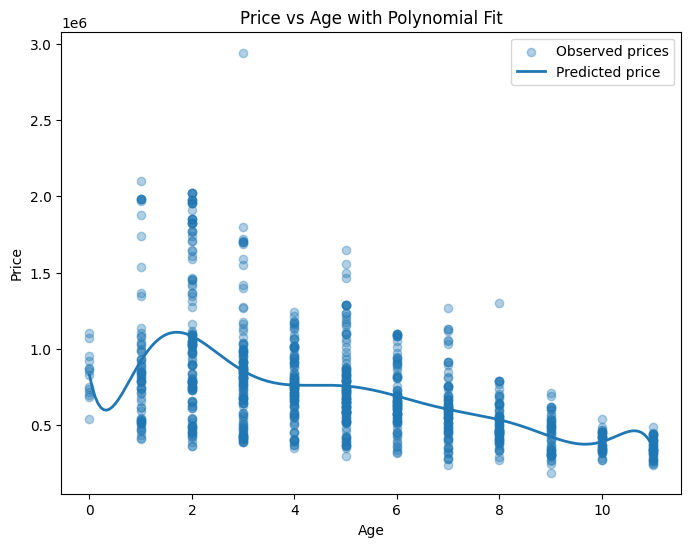

In [37]:
# 3.4
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

best_degree = 9

best_model = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('linreg', LinearRegression())
])

best_model.fit(df[['Age']], df['Price'])

age_grid = np.linspace(df['Age'].min(), df['Age'].max(), 200)
predicted_price = best_model.predict(pd.DataFrame({'Age': age_grid}))

plt.figure(figsize=(8,6))
plt.scatter(df['Age'], df['Price'], alpha=0.35, label='Observed prices')
plt.plot(age_grid, predicted_price, linewidth=2, label='Predicted price')
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age with Polynomial Fit')
plt.legend()
plt.show()

# 3.4 answer:
The fitted model captures the general pattern that older cars are cheaper, but it does not fit the data perfectly because there is still a lot of variation in price at each age. So it gets the broad trend right, but not all the detail.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [ ]:
# 4.1
import pandas as pd

df = pd.read_csv('./data/heart_hw.csv')
df.columns = df.columns.str.strip()

if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

group_means = df.groupby('transplant')['y'].mean()
control_survival = group_means['control']
treatment_survival = group_means['treatment']
ate = treatment_survival - control_survival

print("Control survival rate:", round(control_survival, 6))
print("Treatment survival rate:", round(treatment_survival, 6))
print("ATE:", round(ate, 6))

Control survival rate: 0.117647
Treatment survival rate: 0.347826
ATE: 0.230179


# 4.1 answer:

The ATE is 0.230179 so receiving a transplant is associated with about a 23.0 percentage point increase in three-year survival.

In [39]:
# 4.2
import statsmodels.formula.api as smf

df['treat'] = (df['transplant'] == 'treatment').astype(int)

m2 = smf.ols('y ~ treat', data=df).fit()
print(m2.summary())

print("\nCoefficients:")
print(m2.params.round(6))

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Mon, 23 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:31:13   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1176      0.075      1.574      0.1

# 4.2 answer:
When I regress y on transplant status and a constant, the intercept is 0.1176 and the coefficient on treatment is 0.2302. The intercept is the survival probability for the control group, and the treatment coefficient is the difference in survival rates between treatment and control. So this regression reproduces the ATE from part 4.1 exactly.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:31:13   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7020      0.196      3.583      0.0

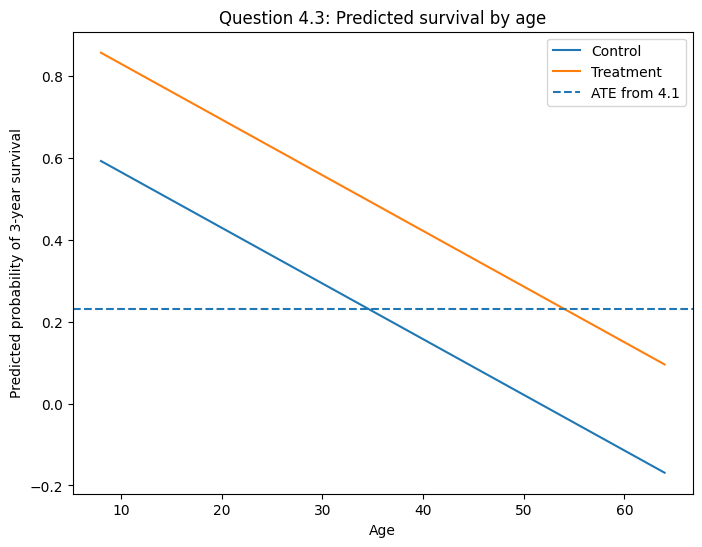

In [ ]:
# 4.3
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

m3 = smf.ols('y ~ treat + age', data=df).fit()
print(m3.summary())

print("\nCoefficients:")
print(m3.params.round(6))

age_grid = np.linspace(df['age'].min(), df['age'].max(), 200)

pred_control = pd.DataFrame({'treat': 0, 'age': age_grid})
pred_treat = pd.DataFrame({'treat': 1, 'age': age_grid})

pred_control['pred_y'] = m3.predict(pred_control)
pred_treat['pred_y'] = m3.predict(pred_treat)

plt.figure(figsize=(8,6))
plt.plot(age_grid, pred_control['pred_y'], label='Control')
plt.plot(age_grid, pred_treat['pred_y'], label='Treatment')
plt.axhline(ate, linestyle='--', label='ATE from 4.1')
plt.xlabel('Age')
plt.ylabel('Predicted probability of 3-year survival')
plt.title('Question 4.3: Predicted survival by age')
plt.legend()
plt.show()

# 4.3 answer:
When I regress y on transplant status and age, the coefficient on treatment becomes 0.2647, which is a little larger than the ATE from part 4.1. The coefficient on age is -0.0136, meaning each additional year of age is associated with about a 1.36 percentage point decrease in predicted three-year survival, holding treatment status fixed. In this model, the treatment effect is constant across all ages, so the ATE from part 4.1 slightly understates the treatment effect at every age.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:31:13   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.3549      0.280      1.269      0.2

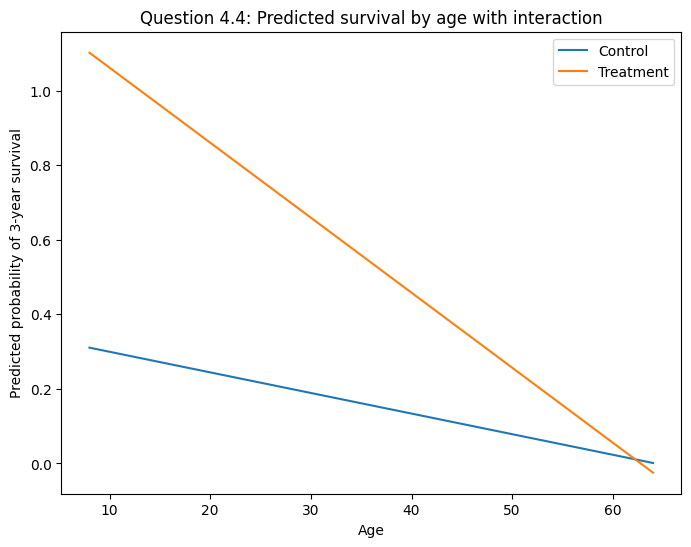

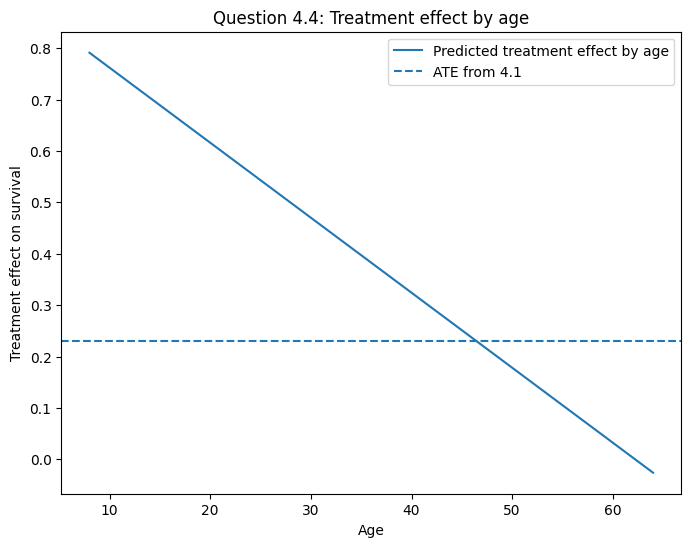

In [ ]:
# 4.4
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

m4 = smf.ols('y ~ treat * age', data=df).fit()
print(m4.summary())

print("\nCoefficients:")
print(m4.params.round(6))

age_grid = np.linspace(df['age'].min(), df['age'].max(), 200)

pred_control_int = pd.DataFrame({'treat': 0, 'age': age_grid})
pred_treat_int = pd.DataFrame({'treat': 1, 'age': age_grid})

pred_control_int['pred_y'] = m4.predict(pred_control_int)
pred_treat_int['pred_y'] = m4.predict(pred_treat_int)

treatment_effect = pred_treat_int['pred_y'] - pred_control_int['pred_y']

plt.figure(figsize=(8,6))
plt.plot(age_grid, pred_control_int['pred_y'], label='Control')
plt.plot(age_grid, pred_treat_int['pred_y'], label='Treatment')
plt.xlabel('Age')
plt.ylabel('Predicted probability of 3-year survival')
plt.title('Question 4.4: Predicted survival by age with interaction')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.plot(age_grid, treatment_effect, label='Predicted treatment effect by age')
plt.axhline(ate, linestyle='--', label='ATE from 4.1')
plt.xlabel('Age')
plt.ylabel('Treatment effect on survival')
plt.title('Question 4.4: Treatment effect by age')
plt.legend()
plt.show()

# 4.4 answer:

When I include the interaction between transplant status and age, the treatment effect is no longer constant. The estimated effect of transplant at age a is: 0.9078−0.0146a

This means the benefit of transplant is larger for younger patients and gets smaller as age increases. So the ATE from part 4.1 is too small for younger patients and too large for older patients. This model suggests that age changes the size of the treatment effect.

In [43]:
# 4.5
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression

X_treat = df[['transplant']]
X_full = df[['transplant', 'age']]
y = df['y']

cv = KFold(n_splits=10, shuffle=True, random_state=42)

# y ~ transplant
pipe2 = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), ['transplant'])
    ])),
    ('model', LinearRegression())
])

# y ~ transplant + age
pipe3 = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), ['transplant']),
        ('num', 'passthrough', ['age'])
    ])),
    ('model', LinearRegression())
])

# y ~ transplant * age
pipe4 = Pipeline([
    ('pre', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), ['transplant']),
        ('num', 'passthrough', ['age'])
    ])),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('model', LinearRegression())
])

scores2 = cross_validate(pipe2, X_treat, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))
scores3 = cross_validate(pipe3, X_full, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))
scores4 = cross_validate(pipe4, X_full, y, cv=cv, scoring=('neg_mean_squared_error', 'r2'))

cv_results = pd.DataFrame({
    'Model': ['transplant only', 'transplant + age', 'transplant * age'],
    'Mean CV MSE': [
        -scores2['test_neg_mean_squared_error'].mean(),
        -scores3['test_neg_mean_squared_error'].mean(),
        -scores4['test_neg_mean_squared_error'].mean()
    ],
    'Mean CV RMSE': [
        np.sqrt(-scores2['test_neg_mean_squared_error'].mean()),
        np.sqrt(-scores3['test_neg_mean_squared_error'].mean()),
        np.sqrt(-scores4['test_neg_mean_squared_error'].mean())
    ],
    'Mean CV R^2': [
        scores2['test_r2'].mean(),
        scores3['test_r2'].mean(),
        scores4['test_r2'].mean()
    ]
})

print(cv_results.round(6))

              Model  Mean CV MSE  Mean CV RMSE  Mean CV R^2
0   transplant only     0.193069      0.439396    -0.041654
1  transplant + age     0.177267      0.421030     0.022490
2  transplant * age     0.175120      0.418474     0.043372


# 4.5 answer: 
Using 10-fold cross validation, the interaction model performs best, although only slightly better than the model with transplant and age but no interaction. The transplant-only model performs worst. This suggests that age improves prediction, and allowing the transplant effect to vary by age helps a little more.

# 4.6 answer:

I would be cautious about using this model to prioritize transplant access. The dataset is small, the treatment is not randomly assigned, and the model only includes age and transplant status, leaving out many important medical factors. It is also a linear probability model, so it can produce unrealistic predicted probabilities. Because of this, the model could be biased or unfair, especially if it were used to make high-stakes decisions about who should receive an organ.